In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/generate_dataset.py
/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv


In [6]:
df = pd.read_csv('/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv')

In [7]:
df

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low


In [8]:
df_diabet_risk = df['diabetes_risk']
df_diabet_risk.value_counts()

diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64

In [9]:
df = pd.read_csv('/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv')

In [10]:
target_col = 'diabetes_risk'
id_col = 'patient_id'


X = df.drop(columns=[target_col, id_col], errors='ignore')

risk_mapping = {
    'Low': 0, 
    'Moderate': 1, 
    'High': 2
}

# 3. Кодируем y
y = df[target_col].map(risk_mapping)

In [11]:
X


,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High
14996,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN
14997,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low
14998,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low


In [12]:
X.isnull().sum()

age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Size of  X_train: {X_train.shape}")
print(f"Size of  X_test:  {X_test.shape}")

Size of  X_train: (12000, 17)
Size of  X_test:  (3000, 17)


In [14]:
problem_cols = ['alcohol_consumption', 'smoking_status', 'income_bracket']
for col in problem_cols:
    if col in X_train.columns:
        counts = X_train[col].value_counts(dropna=False)
        percent = (X_train[col].value_counts(dropna=False, normalize=True) * 100).round(2)
        summary = pd.DataFrame({'Number: ': counts, 'percent: ': percent})
        print(summary)
        

                     Number:   percent: 
alcohol_consumption                     
Never                    4515      37.62
Occasional               3611      30.09
NaN                      2991      24.92
Regular                   883       7.36
                Number:   percent: 
smoking_status                     
Never               8104      67.53
Current             2347      19.56
Former              1163       9.69
NaN                  386       3.22
                Number:   percent: 
income_bracket                     
Middle              5866      48.88
High                3057      25.48
Low                 2709      22.58
NaN                  368       3.07


In [15]:
smoking_mode = X_train['smoking_status'].mode()[0]
income_mode = X_train['income_bracket'].mode()[0]
X_train['alcohol_consumption'] = X_train['alcohol_consumption'].fillna('Unknown')
X_train['smoking_status'] = X_train['smoking_status'].fillna(smoking_mode)
X_train['income_bracket'] = X_train['income_bracket'].fillna(income_mode)

In [16]:
X_train
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 3489 to 3059
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       12000 non-null  int64  
 1   gender                    12000 non-null  object 
 2   city                      12000 non-null  object 
 3   bmi                       12000 non-null  float64
 4   family_history_diabetes   12000 non-null  object 
 5   physical_activity_level   12000 non-null  object 
 6   diet_type                 12000 non-null  object 
 7   smoking_status            12000 non-null  object 
 8   alcohol_consumption       12000 non-null  object 
 9   hours_sleep_per_night     12000 non-null  float64
 10  stress_level              12000 non-null  int64  
 11  fasting_blood_sugar       12000 non-null  int64  
 12  hba1c_level               12000 non-null  float64
 13  blood_pressure_systolic   12000 non-null  int64  
 14  blood_pre

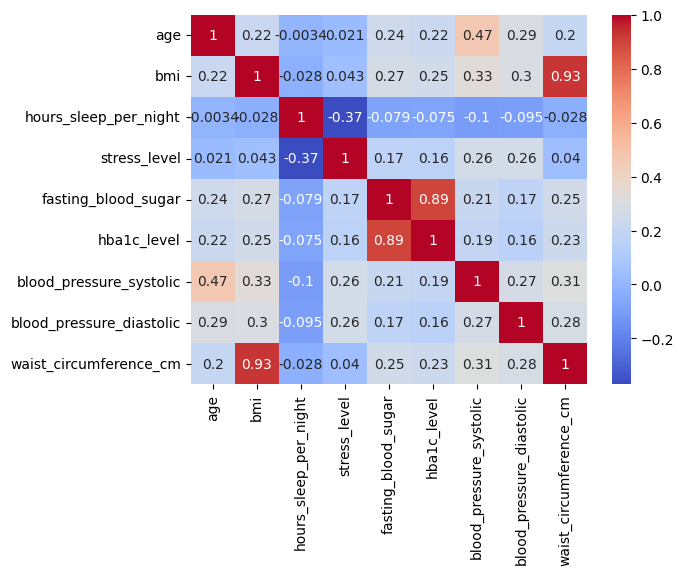

In [17]:
numerical_col = ['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
                'blood_pressure_diastolic', 'waist_circumference_cm']
corr_matrix_num = df[numerical_col].corr(method='spearman')
sns.heatmap(corr_matrix_num, annot=True, cmap='coolwarm')
plt.show()

In [18]:
eda_summary = pd.DataFrame({
    'Тип': X_train.dtypes,
    'Missings (counts)': X_train.isnull().sum(),
    'Missing (%)': (X_train.isnull().mean() * 100).round(2),
    'Unique': X_train.nunique(),
    'Is zero': (X_train == 0).sum()
})
eda_summary

,Тип,Missings (counts),Missing (%),Unique,Is zero
age,int64,0,0.0,57,0
gender,object,0,0.0,3,0
city,object,0,0.0,18,0
bmi,float64,0,0.0,238,0
family_history_diabetes,object,0,0.0,2,0
physical_activity_level,object,0,0.0,3,0
diet_type,object,0,0.0,4,0
smoking_status,object,0,0.0,3,0
alcohol_consumption,object,0,0.0,4,0
hours_sleep_per_night,float64,0,0.0,71,0


In [19]:
X_train

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket
3489,37,Male,Kanpur,18.7,No,Active,Non-Vegetarian,Never,Never,7.9,1,126,6.0,124,96,93.5,Middle
12801,40,Male,Ahmedabad,27.2,Yes,Sedentary,Vegan,Never,Never,9.0,3,213,8.6,130,77,114.4,Middle
1186,43,Female,Bengaluru,21.8,No,Moderate,Non-Vegetarian,Never,Unknown,6.0,10,177,7.2,140,86,96.4,Middle
1949,54,Male,Visakhapatnam,28.8,No,Sedentary,Non-Vegetarian,Current,Occasional,6.0,8,147,6.7,140,97,116.9,Middle
1571,35,Female,Ahmedabad,19.0,Yes,Active,Non-Vegetarian,Never,Never,9.0,5,150,6.7,120,76,86.1,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3478,39,Female,Ahmedabad,16.7,No,Active,Non-Vegetarian,Never,Never,8.0,3,137,6.0,120,80,81.5,High
12338,62,Male,Hyderabad,22.1,No,Active,Non-Vegetarian,Never,Unknown,7.0,7,133,6.3,146,110,96.7,Middle
14701,50,Male,Kolkata,22.1,No,Active,Vegetarian,Current,Never,6.0,5,138,6.0,140,84,103.0,Low
247,55,Other,Hyderabad,20.1,No,Moderate,Vegetarian,Never,Never,8.0,4,161,7.2,141,90,91.4,Middle


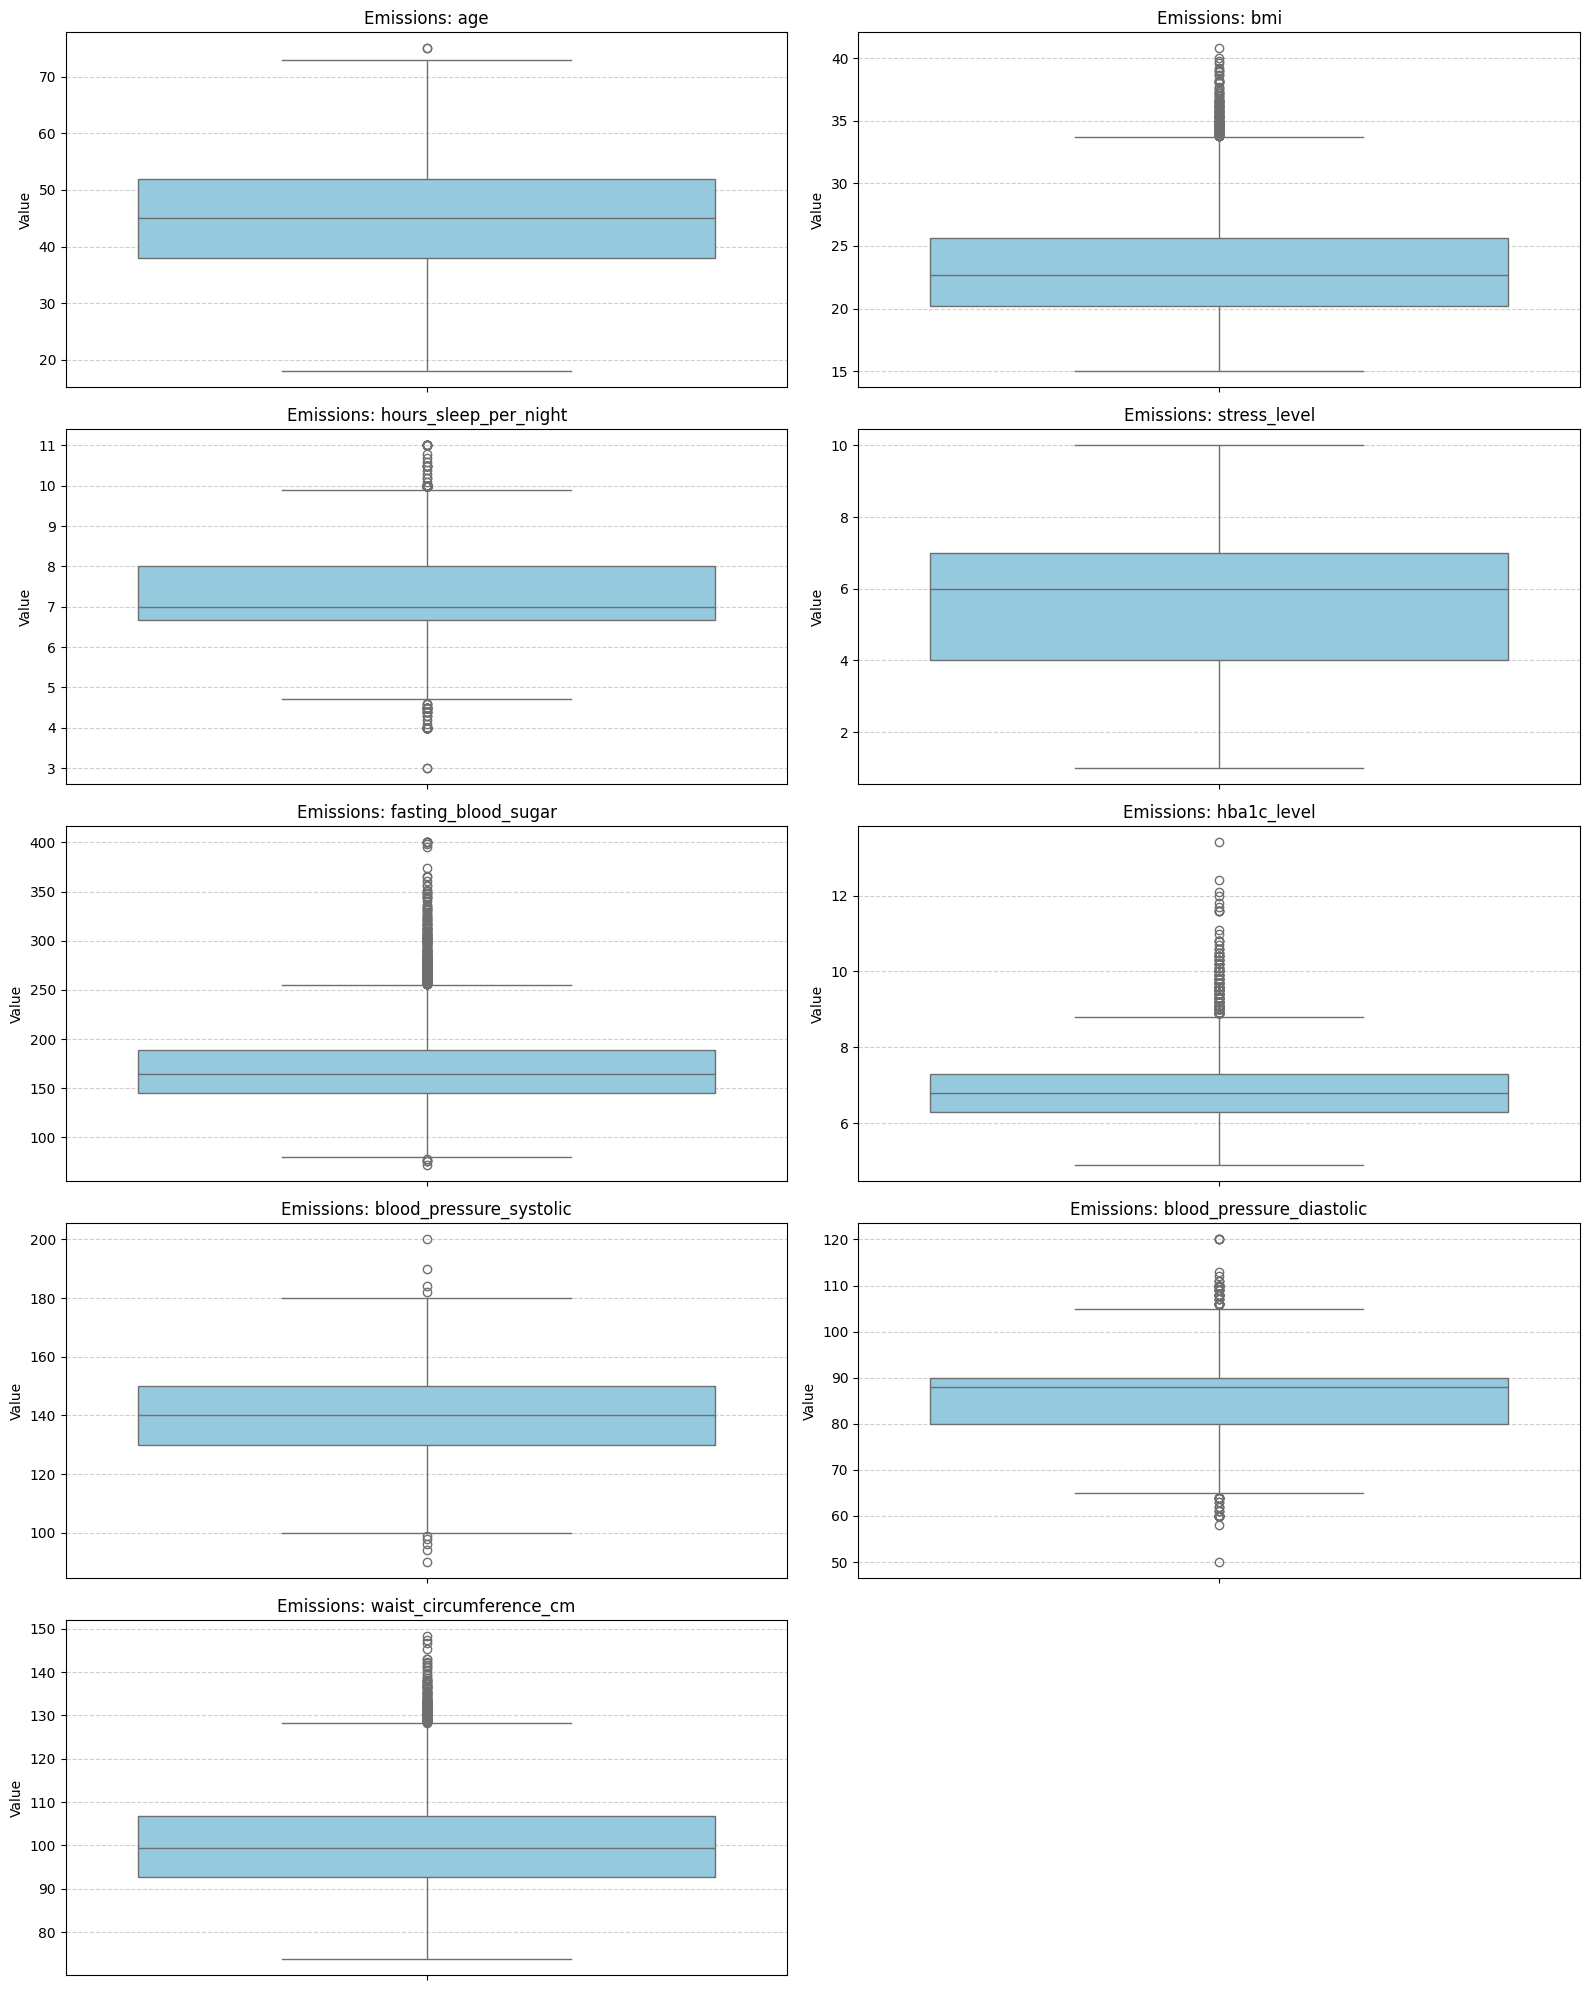

In [20]:
import math
n_cols=2
n_rows = math.ceil(len(numerical_col) / n_cols)
plt.figure(figsize=(16, 20))
for i, col in enumerate(numerical_col, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=X_train[col], color='skyblue')
    plt.title(f'Emissions: {col}', fontsize=12)
    plt.ylabel('Value')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [21]:
X_train['glycemic_index'] = X_train['fasting_blood_sugar'] * X_train['hba1c_level']
X_train['pulse_pressure'] = X_train['blood_pressure_systolic'] - X_train['blood_pressure_diastolic']
X_train['mean_arterial_pressure'] = X_train['blood_pressure_diastolic'] + (X_train['pulse_pressure'] / 3.0)
X_train['lifestyle_stress_ratio'] = X_train['stress_level'] / (X_train['hours_sleep_per_night'] + 1e-5)


In [22]:
new_cols = ['glycemic_index', 'pulse_pressure', 'mean_arterial_pressure', 'lifestyle_stress_ratio']
print(X_train[new_cols].apply(lambda col: col.corr(y_train)).round(3))

glycemic_index            0.749
pulse_pressure            0.100
mean_arterial_pressure    0.231
lifestyle_stress_ratio    0.093
dtype: float64


In [23]:
X_train

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,...,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,glycemic_index,pulse_pressure,mean_arterial_pressure,lifestyle_stress_ratio
3489,37,Male,Kanpur,18.7,No,Active,Non-Vegetarian,Never,Never,7.9,...,126,6.0,124,96,93.5,Middle,756.0,28,105.333333,0.126582
12801,40,Male,Ahmedabad,27.2,Yes,Sedentary,Vegan,Never,Never,9.0,...,213,8.6,130,77,114.4,Middle,1831.8,53,94.666667,0.333333
1186,43,Female,Bengaluru,21.8,No,Moderate,Non-Vegetarian,Never,Unknown,6.0,...,177,7.2,140,86,96.4,Middle,1274.4,54,104.000000,1.666664
1949,54,Male,Visakhapatnam,28.8,No,Sedentary,Non-Vegetarian,Current,Occasional,6.0,...,147,6.7,140,97,116.9,Middle,984.9,43,111.333333,1.333331
1571,35,Female,Ahmedabad,19.0,Yes,Active,Non-Vegetarian,Never,Never,9.0,...,150,6.7,120,76,86.1,High,1005.0,44,90.666667,0.555555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3478,39,Female,Ahmedabad,16.7,No,Active,Non-Vegetarian,Never,Never,8.0,...,137,6.0,120,80,81.5,High,822.0,40,93.333333,0.375000
12338,62,Male,Hyderabad,22.1,No,Active,Non-Vegetarian,Never,Unknown,7.0,...,133,6.3,146,110,96.7,Middle,837.9,36,122.000000,0.999999
14701,50,Male,Kolkata,22.1,No,Active,Vegetarian,Current,Never,6.0,...,138,6.0,140,84,103.0,Low,828.0,56,102.666667,0.833332
247,55,Other,Hyderabad,20.1,No,Moderate,Vegetarian,Never,Never,8.0,...,161,7.2,141,90,91.4,Middle,1159.2,51,107.000000,0.499999


In [24]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MedicalFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_out = X.copy()
        
        # 1. Ранее проверенные непрерывные индексы
        if 'fasting_blood_sugar' in X_out.columns and 'hba1c_level' in X_out.columns:
            X_out['glycemic_index'] = X_out['fasting_blood_sugar'] * X_out['hba1c_level']
            
        if 'blood_pressure_systolic' in X_out.columns and 'blood_pressure_diastolic' in X_out.columns:
            X_out['pulse_pressure'] = X_out['blood_pressure_systolic'] - X_out['blood_pressure_diastolic']
            X_out['mean_arterial_pressure'] = X_out['blood_pressure_diastolic'] + (X_out['pulse_pressure'] / 3.0)
            
        if 'stress_level' in X_out.columns and 'hours_sleep_per_night' in X_out.columns:
            X_out['lifestyle_stress_ratio'] = X_out['stress_level'] / (X_out['hours_sleep_per_night'] + 1e-5)
            
        # 2. Клинические пороговые флаги преддиабета (фокус на класс Moderate)
        if 'fasting_blood_sugar' in X_out.columns:
            # Серая зона сахара натощак: 100 - 125 мг/дл
            X_out['is_prediabetes_glucose'] = (
                (X_out['fasting_blood_sugar'] >= 100) & (X_out['fasting_blood_sugar'] <= 125)
            ).astype(int)
            
        if 'hba1c_level' in X_out.columns:
            # Серая зона гликированного гемоглобина: 5.7% - 6.4%
            X_out['is_prediabetes_hba1c'] = (
                (X_out['hba1c_level'] >= 5.7) & (X_out['hba1c_level'] <= 6.4)
            ).astype(int)
            
        if 'is_prediabetes_glucose' in X_out.columns and 'is_prediabetes_hba1c' in X_out.columns:
            # Совпадение обоих критериев преддиабета
            X_out['both_prediabetes_markers'] = (
                (X_out['is_prediabetes_glucose'] == 1) & (X_out['is_prediabetes_hba1c'] == 1)
            ).astype(int)

        # 3. Пограничная гипертония 1 стадии
        if 'blood_pressure_systolic' in X_out.columns and 'blood_pressure_diastolic' in X_out.columns:
            X_out['is_hypertension_stage1'] = (
                ((X_out['blood_pressure_systolic'] >= 130) & (X_out['blood_pressure_systolic'] < 140)) |
                ((X_out['blood_pressure_diastolic'] >= 80) & (X_out['blood_pressure_diastolic'] < 90))
            ).astype(int)
            
        return X_out

In [25]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, classification_report, confusion_matrix, f1_score

# --- Виправлений список колонок (типи були з помилками) ---
cat_unknown_cols = ['alcohol_consumption']
cat_mode_cols = ['smoking_status']
ordinal_cols = ['income_bracket']
base_num_cols = ['age', 'bmi', 'waist_circumference_cm', 'fasting_blood_sugar',
                  'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic',
                  'hours_sleep_per_night', 'stress_level']
engineered_num_cols = ['glycemic_index', 'pulse_pressure', 'mean_arterial_pressure', 'lifestyle_stress_ratio']
all_num_cols = engineered_num_cols + base_num_cols

pipe_unknown = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
pipe_mode = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
pipe_income = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['Low', 'Middle', 'High']],
                                handle_unknown='use_encoded_value', unknown_value=-1))
])
pipe_num = Pipeline([('imputer', SimpleImputer(strategy='median'))])

preprocessor = ColumnTransformer(transformers=[
    ('cat_unk', pipe_unknown, cat_unknown_cols),
    ('cat_mode', pipe_mode, cat_mode_cols),
    ('ord_inc', pipe_income, ordinal_cols),
    ('num', pipe_num, all_num_cols)
], remainder='drop')

# --- Повний пайплайн: інженерія ознак -> препроцесинг -> модель ---
full_pipeline = Pipeline([
    ('feat_eng', MedicalFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('clf', CatBoostClassifier(
        auto_class_weights='Balanced',   # компенсує дисбаланс класів Low/Moderate/High
        random_state=42,
        verbose=0
    ))
])

# --- Кастомний скорер: пріоритет на recall класу "High" (риск пропустити важкий випадок) ---
recall_high_scorer = make_scorer(recall_score, labels=[2], average='macro')

scoring = {
    'recall_high': recall_high_scorer,
    'f1_macro': make_scorer(f1_score, average='macro')
}

param_grid = {
    'clf__depth': [4, 6, 8],
    'clf__learning_rate': [0.03, 0.1],
    'clf__l2_leaf_reg': [1, 3, 5],
    'clf__iterations': [300, 500]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='recall_high',   # фінальну модель обираємо за recall класу High, не за accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best recall (High class) on CV:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Test set report ---")
print(classification_report(y_test, y_pred, target_names=['Low', 'Moderate', 'High']))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'clf__depth': 4, 'clf__iterations': 300, 'clf__l2_leaf_reg': 5, 'clf__learning_rate': 0.03}
Best recall (High class) on CV: 0.7899999999999999

--- Test set report ---
              precision    recall  f1-score   support

         Low       0.92      0.79      0.85      1800
    Moderate       0.53      0.70      0.60       750
        High       0.75      0.76      0.76       450

    accuracy                           0.76      3000
   macro avg       0.73      0.75      0.74      3000
weighted avg       0.80      0.76      0.77      3000

Confusion matrix:
 [[1425  366    9]
 [ 123  523  104]
 [   3  103  344]]


In [28]:
import numpy as np
from scipy.optimize import minimize
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix


cat_pipeline = Pipeline([
    ('fe', MedicalFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('clf', CatBoostClassifier(
        depth=4,
        iterations=300,
        learning_rate=0.03,
        l2_leaf_reg=5,
        random_seed=42,
        verbose=0
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Генерация Out-of-Fold вероятностей...")
oof_probs = cross_val_predict(
    cat_pipeline, 
    X_train, 
    y_train, 
    cv=cv, 
    method='predict_proba', 
    n_jobs=-1
)


def loss_func(weights):
    scaled_probs = oof_probs * weights
    preds = np.argmax(scaled_probs, axis=1)
    return -f1_score(y_train, preds, average='macro')

init_weights = [1.0, 1.0, 1.0]

res = minimize(
    loss_func, 
    init_weights, 
    method='Nelder-Mead', 
    options={'maxiter': 500}
)

best_weights = res.x / np.sum(res.x)
print("Оптимальные множители вероятностей [Low, Moderate, High]:", np.round(best_weights, 4))

cat_pipeline.fit(X_train, y_train)
test_probs = cat_pipeline.predict_proba(X_test)

y_pred_tuned = np.argmax(test_probs * best_weights, axis=1)


target_names = ['Low', 'Moderate', 'High']
print("\n=== Отчет CatBoost ПОСЛЕ Threshold Tuning ===")
print(classification_report(y_test, y_pred_tuned, target_names=target_names, digits=4))

print("Матрица ошибок (после тюнинга порогов):")
print(confusion_matrix(y_test, y_pred_tuned))

Генерация Out-of-Fold вероятностей...
Оптимальные множители вероятностей [Low, Moderate, High]: [0.2768 0.3868 0.3364]

=== Отчет CatBoost ПОСЛЕ Threshold Tuning ===
              precision    recall  f1-score   support

         Low     0.8802    0.8617    0.8709      1800
    Moderate     0.5533    0.6507    0.5980       750
        High     0.8343    0.6600    0.7370       450

    accuracy                         0.7787      3000
   macro avg     0.7559    0.7241    0.7353      3000
weighted avg     0.7916    0.7787    0.7826      3000

Матрица ошибок (после тюнинга порогов):
[[1551  246    3]
 [ 206  488   56]
 [   5  148  297]]
